In [2]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import importlib

import cmaps, plt_helper, filter
# import subroutines
# import vis_eulag

plt.style.use('latex_default.mplstyle')

In [3]:
folder = "/work/bd0620/b309199/patagonia"
# folder = "/scratch/b/b309199"
region = "debeto"
# region = "pata"
simulations = [f"{region}_1D_pha0", f"{region}_1D_pha1", f"{region}_1D_tide"]

lidar_sets = []
xz_sets = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath, load_ds=False)
    lidar_sets.append(ds_lidars)
    xz_sets.append(ds_xzslices)

In [4]:
importlib.reload(filter)

def plt_xz_avg(ax, axu, dsxz, simlabel=None):
    
    time = dsxz.t * ds.nslice * ds.dt00 / 3600
    temp_res = ds.nslice * ds.dt00 / 60
    zcr = dsxz['zcr'][0,:,0].values
    uw  = dsxz['w'].values * (dsxz['u'].values-dsxz['ue'].values)
    mfx_raw = dsxz['rh0'].values * uw
    mfx_raw = np.mean(mfx_raw[:,:,ix0:ix1], axis=2)
    # _, mfx = filter.butterworth_filter(mfx_raw, cutoff=1/VERTICAL_CUTOFF, fs=1/ds.dz00, order=5, mode='both')
    mfx_raw = filter.gaussian_fft_smoothing(mfx_raw, TEMPORAL_CUTOFF, VERTICAL_CUTOFF, temp_res, ds.dz00)
    mfx = mfx_raw * 1000
    izcut = int(70000 / ds.dz00)
    mfx[:,izcut:] = mfx[:,izcut:] * 10**3
    contf = ax.contourf(time, zcr, mfx.T, levels=clev_mf, cmap=cmap_mf, norm=norm_mf, extend='both')

    ## Plot critical level (ue = 0)
    zcrit = []
    for t in range(0,len(dsxz.t)):
        ue = dsxz['ue'].values[t,:,0]
        izcrit = np.where(np.diff(np.sign(ue)) != 0)[0][0]
        if izcrit < 275:
            zcrit.append(zcr[izcrit])
        else:
            zcrit.append(np.nan)
    ax.plot(time, zcrit, lw=2, color='black',ls='--', label='Critical level (MWs)')

    ## Plot udiff
    lwdot = 2
    upper_range = [80000, 100000]
    lower_range = [45000, 65000]
    i95 = [int(upper_range[0] / ds.dz00), int(upper_range[1] / ds.dz00)]
    i55 = [int(lower_range[0] / ds.dz00), int(lower_range[1] / ds.dz00)]
    udiff = np.mean(dsxz['u'][:,:,ix0:ix1].values, axis=2) - dsxz['ue'][:,:,0].values
    udiff95 = np.mean(udiff[:,i95[0]:i95[1]], axis=1)
    udiff55 = np.mean(udiff[:,i55[0]:i55[1]], axis=1)
    axu.plot(time, udiff95, lw=1, color='royalblue', ls='-', label=f"{int(upper_range[0]/1000)}-{int(upper_range[1]/1000)}km")
    axu.plot(time, udiff55, lw=lwdot, color='royalblue', ls='dotted', label=f"{int(lower_range[0]/1000)}-{int(lower_range[1]/1000)}km")

    axu.set_ylim(-34,34)
    axu.tick_params(labelbottom=False,labeltop=True, labelleft=False)
    axu.yaxis.set_major_locator(MultipleLocator(10))
    axu.yaxis.set_minor_locator(AutoMinorLocator())
    axu.xaxis.set_label_position('top')
    axu.set_xlabel('time / h')
    axu.grid()
    
    ## Plot GWD
    axgwd = axu.twinx()
    # mfx_raw = filter.gaussian_fft_smoothing(mfx_raw, 1, 20*1000, 1, ds.dz00)
    gwd = -np.gradient(mfx_raw, ds.dz00, axis=1) / np.mean(dsxz['rh0'][:,:,ix0:ix1].values, axis=2)
    gwd95 = np.mean(gwd[:,i95[0]:i95[1]], axis=1) * 86400 # convert to m/s/day
    gwd55 = np.mean(gwd[:,i55[0]:i55[1]], axis=1) * 86400
    axgwd.plot(time, gwd95, lw=1, color='indianred', ls='-')
    axgwd.plot(time, gwd55, lw=lwdot, color='indianred', ls='dotted')

    axgwd.tick_params(labelbottom=False,labeltop=False, labelright=False)
    axgwd.yaxis.set_minor_locator(AutoMinorLocator())
    axgwd.set_ylim(-600,600)
    if axu == axes[0,2]:
        axgwd.tick_params(labelright=True)
        axgwd.set_ylabel('GWD / m$\,$s$^{-1}\,$day$^{-1}$', color='indianred')
        axgwd.tick_params(axis='y', labelcolor='indianred')
        axgwd.spines['right'].set_color('indianred')
        axgwd.spines['left'].set_linewidth(2)
    
    
    
    ax.tick_params(labelbottom=False,labeltop=False, labelleft=False)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlim(tlim)
    ax.set_ylim(zlim)
    ax.grid()
    
    if simlabel is not None:
        ax.text(0.5, 0.04, simlabel, transform=ax.transAxes, horizontalalignment='center', weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    return ax, contf

Region: debeto ([np.float64(-103200.0), np.float64(103200.0)])


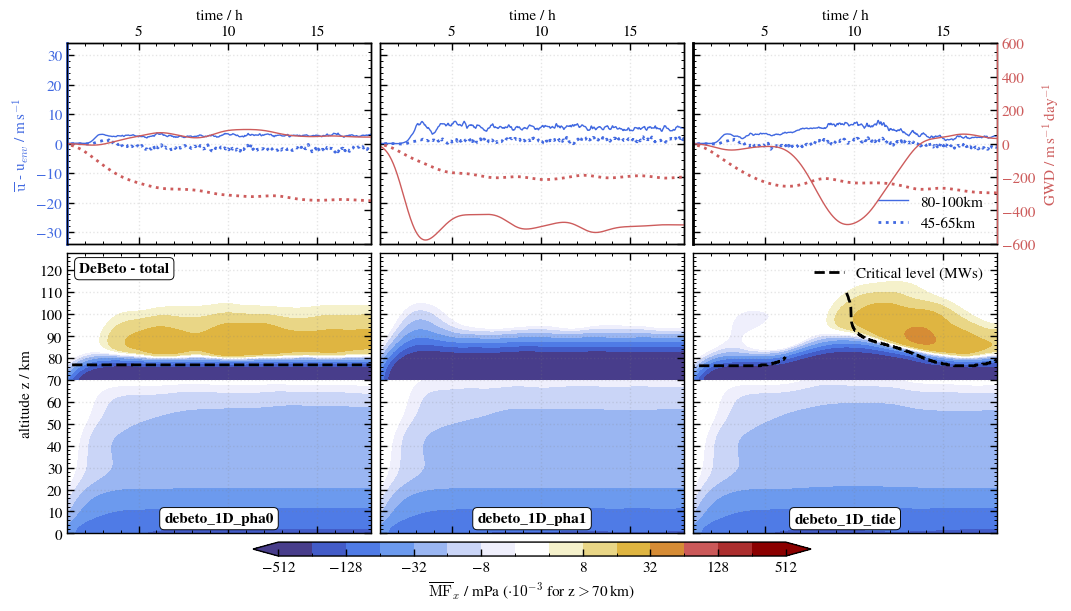

In [11]:
area = "upstream"
area = "downstream"
area = "total"

if region=="debeto":
    xsep = 0*1000
else:
    xsep = -200*1000

if area == "upstream":
    xrange = [ds.xcr.min().values*1000+ds.dxabL, xsep]
elif area == "downstream":
    xrange = [xsep, ds.xcr.max().values*1000-ds.dxabR]
else:
    xrange = [ds.xcr.min().values*1000+ds.dxabL, ds.xcr.max().values*1000-ds.dxabR]

print(f"Region: {region} ({xrange})")
ix0 = int(xrange[0] / ds.dx00 + ds.nx / 2)
ix1 = int(xrange[1] / ds.dx00 + ds.nx / 2)

VERTICAL_CUTOFF = 15*1000 # m (LAMBDA_CUT)
TEMPORAL_CUTOFF = 3*60 # min (TAU_CUT)
ds_lid = lidar_sets[0][0]

tlim = [ds_lid.time.max().values-17,ds_lid.time.max().values]
# zlim = [0,ds_lid.zcr.max().values]
zlim = [0,128]

# xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
# ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]

cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_ep = plt.get_cmap('YlOrRd')
# clev_ep, clev_l_ep = plt_helper.get_colormap_bins_and_labels(max_level=32)
# clev_ep = np.arange(50,500,50)
clev_ep = [4,8,16,32,64,128,256,512,1024]
norm_ep = BoundaryNorm(boundaries=clev_ep, ncolors=cmap_ep.N, clip=True)

cmap_mf = plt.get_cmap('RdBu_r')
cmap_mf = plt.get_cmap('bwr')
cmap_mf   = cmaps.get_wave_cmap()
# cmap_mf = plt.get_cmap('coolwarm')
# cmap_mf = plt.get_cmap('Spectral')
clev_mf, clev_l_mf = plt_helper.get_colormap_bins_and_labels(max_level=256)
norm_mf = BoundaryNorm(boundaries=clev_mf, ncolors=cmap_mf.N, clip=True)


"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [5,7,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(3,3, sharex=True, figsize=(12,7), gridspec_kw=gskw)

for ax in axes[-1,0:3]:
    ax.set_axis_off()

axes[1,0], contf = plt_xz_avg(axes[1,0], axes[0,0], xz_sets[0][0], simlabel=simulations[0])
axes[1,1], _     = plt_xz_avg(axes[1,1], axes[0,1], xz_sets[1][0], simlabel=simulations[1])
axes[1,2], _     = plt_xz_avg(axes[1,2], axes[0,2], xz_sets[2][0], simlabel=simulations[2])

xpp = 0.96
ypp = 0.93

if region == "pata":
    mystring = f"Fitzroy ridge - {area}"
else:
    mystring = f"DeBeto - {area}"
axes[1,0].text(1-xpp, ypp, mystring, transform=axes[1,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

axes[1,0].tick_params(labelleft=True)
# axes[0,0].yaxis.set_label_position('right')
axes[1,0].set_ylabel('altitude z / km')

axes[0,0].tick_params(labelleft=True)
axes[0,0].tick_params(axis='y', labelcolor='royalblue')
axes[0,0].set_ylabel(r'$\overline{\mathrm{u}}$ - u$_{env}$ / m$\,$s$^{-1}$', color='royalblue')
axes[0,0].spines['left'].set_color('royalblue')
axes[0,0].spines['left'].set_linewidth(2)

axes[0,2].legend(frameon=False, loc='lower right')
axes[1,2].legend(frameon=False)

cbar = fig.colorbar(contf, ax=axes[-1,:], orientation='horizontal', ticks=clev_l_mf, shrink=0.6, fraction=1, aspect=40)
cbar.set_label(r"$\overline{\mathrm{MF}}_x$ / mPa ($\cdot 10^{-3}$ for z$>$70$\,$km)")
# cbar.ax.xaxis.set_ticks_position('top')
# cbar.ax.xaxis.set_label_position('top')

fig_title = f"mfx_gwd_over_time_{region}_{area}.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')

In [25]:
xz_sets[0][0]

<xarray.Dataset> Size: 819MB
Dimensions:  (t: 151, z: 321, x: 384)
Dimensions without coordinates: t, z, x
Data variables:
    u        (t, z, x) float32 74MB 0.0 0.0 0.0 0.0 ... 5.018 2.365 -0.1412
    v        (t, z, x) float32 74MB ...
    w        (t, z, x) float32 74MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    th       (t, z, x) float32 74MB ...
    zcr      (t, z, x) float32 74MB 0.0 0.0 0.0 0.0 ... 128.0 128.0 128.0 128.0
    ue       (t, z, x) float32 74MB 0.0 0.0 0.0 0.0 ... -0.1412 -0.1412 -0.1412
    ve       (t, z, x) float32 74MB ...
    the      (t, z, x) float32 74MB ...
    ppe      (t, z, x) float32 74MB ...
    p        (t, z, x) float32 74MB ...
    rh0      (t, z, x) float32 74MB 1.244 1.244 1.244 ... 5.004e-09 5.004e-09
Attributes:
    j:        134
    ypos:     -232.0

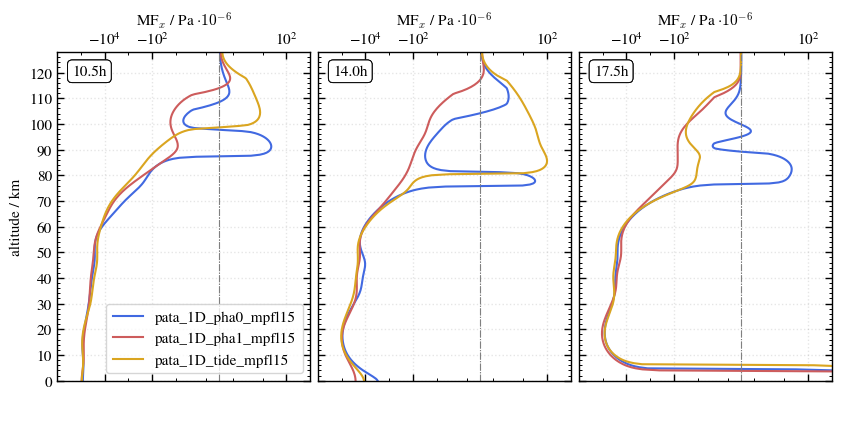

In [60]:
"""Compare vertical profiles of MFx and GWD for different simulations"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [7,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(10,5), gridspec_kw=gskw)
for ax in axes[-1,0:3]:
    ax.set_axis_off()
    
global lambdax, lambdaz
lambdax = 150 * 1000 # m 
lambdaz =  20 * 1000 # m 
zlim = [0,128]
cols = ["royalblue", "indianred", "goldenrod"]
timestamps = [90,120,150]

xrange = [-250*1000, 150*1000]
ix0 = int(xrange[0] / ds.dx00 + ds.nx / 2)
ix1 = int(xrange[1] / ds.dx00 + ds.nx / 2)

for i,sets in enumerate(xz_sets):
    dsxz = sets[0]
    zcr = dsxz['zcr'][0,:,0].values / 1000
    uw  = dsxz['w'].values * (dsxz['u'].values-dsxz['ue'].values)
    mfx_slc = dsxz['rh0'].values * uw
    mfx_slc = np.mean(mfx_slc[:,:,ix0:ix1], axis=2)

    # print(np.shape(mfx_slc))
    for j,t in enumerate(timestamps):
        ax = axes[0,j]
        mfx = mfx_slc[t,:]
        mfx = plt_helper.gaussian_filter_fft_1D(mfx, lambdaz, ds.dz00)
        mfx = mfx * 10**6
        if j == 0:
            ax.plot(mfx, zcr, lw=1.5, ls='-', color=cols[i], label=simulations[i])
        else:
            ax.plot(mfx, zcr, lw=1.5, ls='-', color=cols[i])
        # ax_t.plot(tenv, zcr, lw=1.5, ls='--', color="coral")
        ax.set_xlabel('MF$_x$ / Pa $\cdot 10^{-6}$')
        ax.set_xlim([-10**6,10**3])
        ax.set_xscale("symlog")
        ax.set_xticks([-10**4,-10**2, 10**2])
        ax.vlines(x=[0], ymin=0,ymax=zlim[1], colors="grey", lw=0.75, ls='-.')
        ax.xaxis.set_label_position('top')
        ax.tick_params(which='both', top=True, bottom=True, labelbottom=False, labeltop=True)
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.grid()
        ax.set_ylim(zlim)
        ax.text(0.06,0.93, f"{t * ds.dt00 * ds.nslice / 3600}h", transform=ax.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

axes[0,0].set_ylabel("altitude / km")
axes[0,0].tick_params(which='both', top=True, bottom=True, labelbottom=False, labeltop=True, labelleft=True)
axes[0,0].legend()

fig_title = "xz_profiles_mf_temp.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')
